# 5.0 Model training - LightGBM - Optuna search


## Imports


In [1]:
import numpy as np
import pandas as pd
import joblib
import shap
import mlflow
import matplotlib.pyplot as plt
from optuna.importance import get_param_importances
from recruit_restaurant_visitor_forecasting.config.config import (
    MODELS_DIR,
    VISIT_DATE_COL,
    RANDOM_SEED,
    AIR_GENRE_COL,
    PROCESSED_DATA_DIR,
    VISITORS_COL
)
from recruit_restaurant_visitor_forecasting.config.features import CITY_COL, RES_OFFSET, GOLDEN_WEEK_FLG
from recruit_restaurant_visitor_forecasting.config.preprocessing import (
    REMAINING_FEATURES,
    EMPTY_DATES_RANGE,
    RES_MAX_OFFSET
)
from recruit_restaurant_visitor_forecasting.config.modeling import (
    CV_SPLITS,
    TEST_SIZE,
    FIRST_ITER_TRIALS,
    SECOND_ITER_TRIALS,
    FS_VALID_SIZE,
    OBJECTIVE_FUNCTION
)
from recruit_restaurant_visitor_forecasting.modeling.train import (
    load_data,
    prepare_features,
    shap_fs,
    lgbm_optuna_search,
    train_test_split_by_date,
)
from recruit_restaurant_visitor_forecasting.plots import (
    plot_actual_pred,
    plot_daily_error_overall,
    plot_daily_error_by_group,
    plot_error_mean_std,
    plot_error_radar,
    plot_errors_boxplot
)
from recruit_restaurant_visitor_forecasting.utils import (
    merge_daily_pred,
    get_format,
    optuna_cv_results_to_df,
    get_daily_error_stats_table,
    MEAN_ERROR,
    STD_ERROR,
    MIN_ABS_ERROR,
    MAX_POS_ERROR,
    MAX_NEG_ERROR,
    get_metrics,
    rmsle,
    mix_reservation_features
)
from recruit_restaurant_visitor_forecasting.modeling.predict import recursive_predict
from recruit_restaurant_visitor_forecasting.eda import print_best_params

2026-05-24 20:31:10.957 | INFO     | recruit_restaurant_visitor_forecasting.config.config:<module>:12 - PROJ_ROOT path is: D:\mentoring_program


In [2]:
MODEL_NAME = "lgbm_30it_no_updating_agg_cols"
MODEL_PATH = MODELS_DIR / f"{MODEL_NAME}_model.pkl"
MLFLOW_WORK = True
GW_DATE = pd.date_range("2016-05-03", "2016-05-05")
MIX_RESERVATIONS = True
INCLUDE_GAP = False

if MLFLOW_WORK:
    mlflow.set_experiment(f"recruit_restaurant_visitors_v05")

## Load and prepare

In [3]:
features, labels = load_data()
features = prepare_features(features)
labels = labels.loc[features.index].reset_index(drop=True)
features = features.reset_index(drop=True)

In [4]:
X = features
y = labels
X[RES_OFFSET] = 1

X_train, X_test, y_train, y_test = train_test_split_by_date(
    X, y, date_col=VISIT_DATE_COL, test_size=TEST_SIZE
)

train_dates = X_train[VISIT_DATE_COL]
test_dates = X_test[VISIT_DATE_COL]

print(f"Train set dates: {train_dates.min()} to {train_dates.max()}")
print(f"Test set dates: {test_dates.min()} to {test_dates.max()}")

Train set dates: 2016-02-01 00:00:00 to 2017-03-08 00:00:00
Test set dates: 2017-03-09 00:00:00 to 2017-04-22 00:00:00


C:\Users\lymuthien\AppData\Local\Temp\ipykernel_29540\615688793.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X[RES_OFFSET] = 1


In [5]:
DROP_COLUMNS = features.columns.difference(REMAINING_FEATURES).to_list()

### Reservation mixing

In [8]:
if MIX_RESERVATIONS:
    X_train = mix_reservation_features(X_train, RES_MAX_OFFSET, seed=RANDOM_SEED)
else:
    DROP_COLUMNS += [RES_OFFSET]

### Gap period

In [9]:
if not INCLUDE_GAP:
    gap_mask = X_train[VISIT_DATE_COL].isin(pd.to_datetime(EMPTY_DATES_RANGE))
    X_train_without_gap = X_train[~gap_mask]
    y_train_without_gap = y_train[~gap_mask]

### Iteration 1

In [10]:
study, model = lgbm_optuna_search(
    X_train_without_gap,
    y_train_without_gap,
    n_jobs=8,
    drop_features=DROP_COLUMNS,
    n_trials=FIRST_ITER_TRIALS,
    n_splits=CV_SPLITS,
    random_state=RANDOM_SEED,
    window_test_size=39,
    mlflow_run_name="study_first_iter",
    objective_func=OBJECTIVE_FUNCTION,
    extra_score_date=GW_DATE,
    X_full=X_train,
    y_full=y_train,
)
print_best_params(study)

[I 2026-05-24 15:03:24,416] A new study created in memory with name: no-name-1472a202-10d8-4281-aa3c-8a8c9f414413
Predicting recursively: 100%|██████████| 3/3 [00:02<00:00,  1.10it/s]
[I 2026-05-24 15:05:13,733] Trial 0 finished with value: 1.242706390097293 and parameters: {'model__max_depth': 3, 'model__learning_rate': 0.10123837206820968, 'model__n_estimators': 532, 'model__subsample': 0.5797899627499927, 'model__colsample_bytree': 0.8976596887590331, 'model__min_child_samples': 195, 'model__reg_alpha': 0.00045752883830580044, 'model__reg_lambda': 0.0001412383615170946, 'model__num_leaves': 5, 'model__tweedie_variance_power': 1.5186888701623777}. Best is trial 0 with value: 1.242706390097293.
Predicting recursively: 100%|██████████| 3/3 [00:02<00:00,  1.11it/s]
[I 2026-05-24 15:06:37,591] Trial 6 finished with value: 1.2405304525154641 and parameters: {'model__max_depth': 5, 'model__learning_rate': 0.014037556549741228, 'model__n_estimators': 460, 'model__subsample': 0.7615367100314

Best parameters: {'model__max_depth': 5, 'model__learning_rate': 0.010104546702254179, 'model__n_estimators': 179, 'model__subsample': 0.8388853167659395, 'model__colsample_bytree': 0.7129041728404595, 'model__min_child_samples': 51, 'model__reg_alpha': 0.20898062399805456, 'model__reg_lambda': 0.2118797675832298, 'model__num_leaves': 25, 'model__tweedie_variance_power': 1.278496022261901}
Best score: 1.21491


In [11]:
optuna_cv_results_to_df(study).sort_values(["rank_test_score"]).head()

,params,std_test_score,mean_test_score,split_test_0,split_test_1,split_test_2,split_test_3,split_test_4,split_test_5,rank_test_score
17,"{'model__max_depth': 5, 'model__learning_rate'...",0.204989,1.214906,0.997899,1.354618,1.014301,1.350160,1.044563,1.527892,1
29,"{'model__max_depth': 5, 'model__learning_rate'...",0.275044,1.215495,0.941325,1.584955,0.945272,1.315336,0.973383,1.532698,2
14,"{'model__max_depth': 5, 'model__learning_rate'...",0.448676,1.225273,0.840243,2.033437,0.821642,1.275438,0.845026,1.535852,3
27,"{'model__max_depth': 5, 'model__learning_rate'...",0.363005,1.228106,0.893990,1.836618,0.885862,1.275823,0.930678,1.545663,4
21,"{'model__max_depth': 5, 'model__learning_rate'...",0.460081,1.236257,0.852083,2.081701,0.828065,1.262592,0.852157,1.540945,5


### SHAP feature selection

In [153]:
selected_features, feature_stats = shap_fs(
    X_train,
    y_train,
    model.named_steps["model"],
    drop_features=DROP_COLUMNS,
    test_size=FS_VALID_SIZE,
)

### Iteration 2

In [169]:
study, model_shap = lgbm_optuna_search(
    X_train_without_gap,
    y_train_without_gap,
    n_jobs=8,
    drop_features=DROP_COLUMNS,
    n_trials=SECOND_ITER_TRIALS,
    n_splits=CV_SPLITS,
    random_state=RANDOM_SEED,
    features_top=selected_features,
    window_test_size=39,
    mlflow_run_name="study_second_iter",
    objective_func=OBJECTIVE_FUNCTION,
    extra_score_date=GW_DATE,
    X_full=X_train,
    y_full=y_train,
)
print_best_params(study)

[I 2026-05-19 17:14:20,093] A new study created in memory with name: no-name-d254c045-6677-45c5-bcef-94ecb15f4405
Predicting recursively: 100%|██████████| 3/3 [00:03<00:00,  1.01s/it]
[I 2026-05-19 17:19:42,924] Trial 4 finished with value: 1.2227095723383548 and parameters: {'model__max_depth': 5, 'model__learning_rate': 0.010473491997821705, 'model__n_estimators': 538, 'model__subsample': 0.6326190886424968, 'model__colsample_bytree': 0.7956244098997994, 'model__min_child_samples': 17, 'model__reg_alpha': 0.1910549518986201, 'model__reg_lambda': 1.2566725503765008, 'model__num_leaves': 18, 'feature_dropper__keep_count': 34}. Best is trial 4 with value: 1.2227095723383548.
Predicting recursively: 100%|██████████| 3/3 [00:04<00:00,  1.58s/it]
[I 2026-05-19 17:20:46,695] Trial 3 finished with value: 1.2411767072434907 and parameters: {'model__max_depth': 4, 'model__learning_rate': 0.025759862125081717, 'model__n_estimators': 566, 'model__subsample': 0.6403091322999275, 'model__colsample

Best parameters: {'model__max_depth': 4, 'model__learning_rate': 0.2696777551092835, 'model__n_estimators': 294, 'model__subsample': 0.9973772720060743, 'model__colsample_bytree': 0.9569406074548042, 'model__min_child_samples': 10, 'model__reg_alpha': 0.020531236650358626, 'model__reg_lambda': 0.002501636225671861, 'model__num_leaves': 11, 'feature_dropper__keep_count': 38}
Best score: 1.08823


In [170]:
cv_results = optuna_cv_results_to_df(study)
cv_results.sort_values(["rank_test_score"]).head()

,params,std_test_score,mean_test_score,split_test_0,split_test_1,split_test_2,split_test_3,split_test_4,split_test_5,rank_test_score
132,"{'model__max_depth': 4, 'model__learning_rate'...",0.261400,1.088231,0.869890,1.138356,0.838223,1.344072,0.838776,1.500066,1
54,"{'model__max_depth': 4, 'model__learning_rate'...",0.269772,1.088444,0.841773,1.154218,0.828507,1.340338,0.849282,1.516546,2
139,"{'model__max_depth': 4, 'model__learning_rate'...",0.267182,1.089763,0.852590,1.193212,0.824131,1.319204,0.840261,1.509180,3
174,"{'model__max_depth': 4, 'model__learning_rate'...",0.268831,1.090744,0.856386,1.170109,0.826700,1.338489,0.839768,1.513013,4
84,"{'model__max_depth': 4, 'model__learning_rate'...",0.268021,1.090780,0.869194,1.130733,0.843445,1.310571,0.842555,1.548182,5


### Scores

In [12]:
y_train_pred = model.predict(X_train)
y_train_pred = np.maximum(y_train_pred, 0)

print("Train set")
get_metrics(y_train, y_train_pred)

Train set


RMSLE      0.840477
MAE        6.751631
MSE      109.536636
dtype: float64

In [18]:
y_test_pred, test_temp = recursive_predict(
    model, X_test, X_train, y_train, update_reservations=True, update_dow_agg=False
)

Predicting recursively: 100%|██████████| 45/45 [00:05<00:00,  7.59it/s]


In [93]:
test_rmsle = rmsle(y_test, y_test_pred)
print("Test set")
get_metrics(y_test, y_test_pred)

Test set


RMSLE      0.859602
MAE        7.498172
MSE      159.109036
dtype: float64

## Graphs

### Optuna importances

In [14]:
get_param_importances(study)

{'model__n_estimators': np.float64(0.8861723274048096),
 'model__learning_rate': np.float64(0.05573067434796687),
 'model__max_depth': np.float64(0.036539359180611644),
 'model__min_child_samples': np.float64(0.008002482240223327),
 'model__subsample': np.float64(0.006847453023811735),
 'model__colsample_bytree': np.float64(0.00466055705366801),
 'model__reg_alpha': np.float64(0.0014047699660848427),
 'model__reg_lambda': np.float64(0.0006423767828239784)}

### SHAP explanation

In [162]:
X_test_clean = model.named_steps["feature_dropper"].transform(X_test)
lgbm = model.named_steps["model"]

explainer = shap.TreeExplainer(lgbm)
shap_values = explainer(X_test_clean)

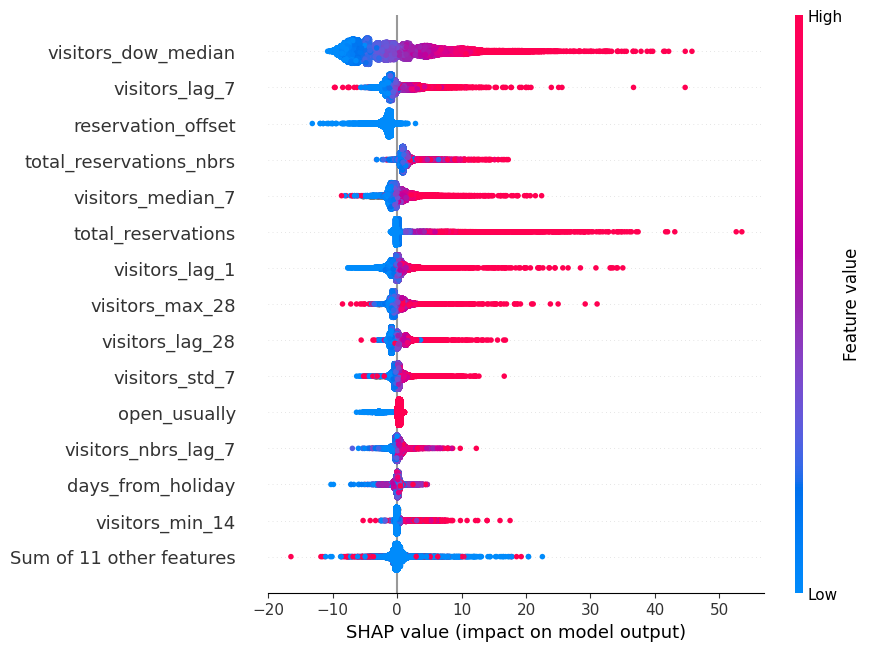

In [178]:
shap.plots.beeswarm(shap_values, max_display=15)

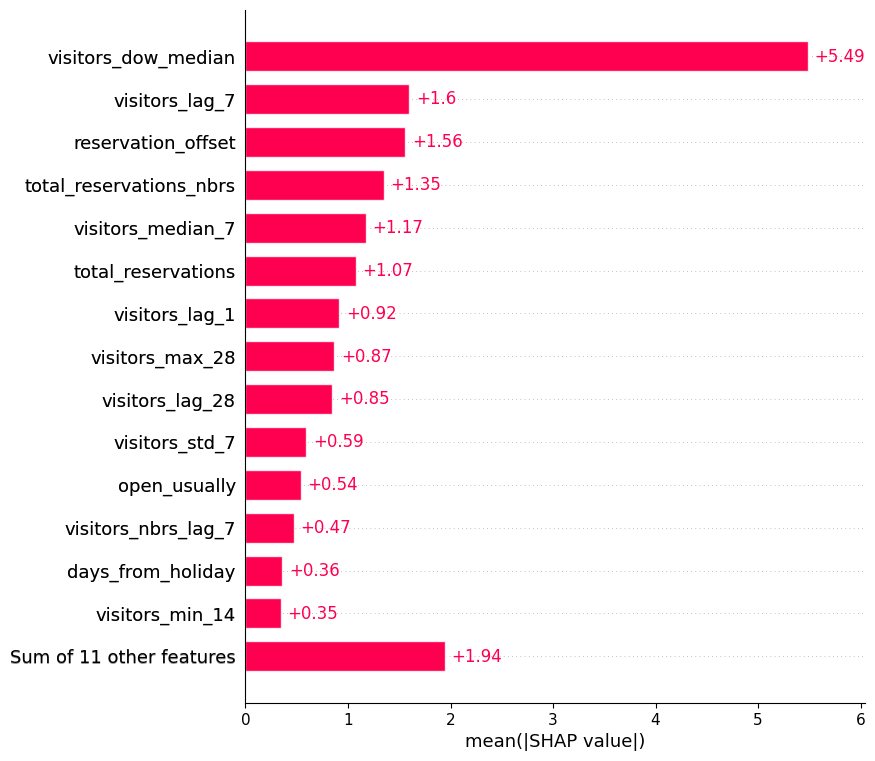

In [179]:
shap.plots.bar(shap_values, max_display=15)

### Visitors per day: actual vs predicted

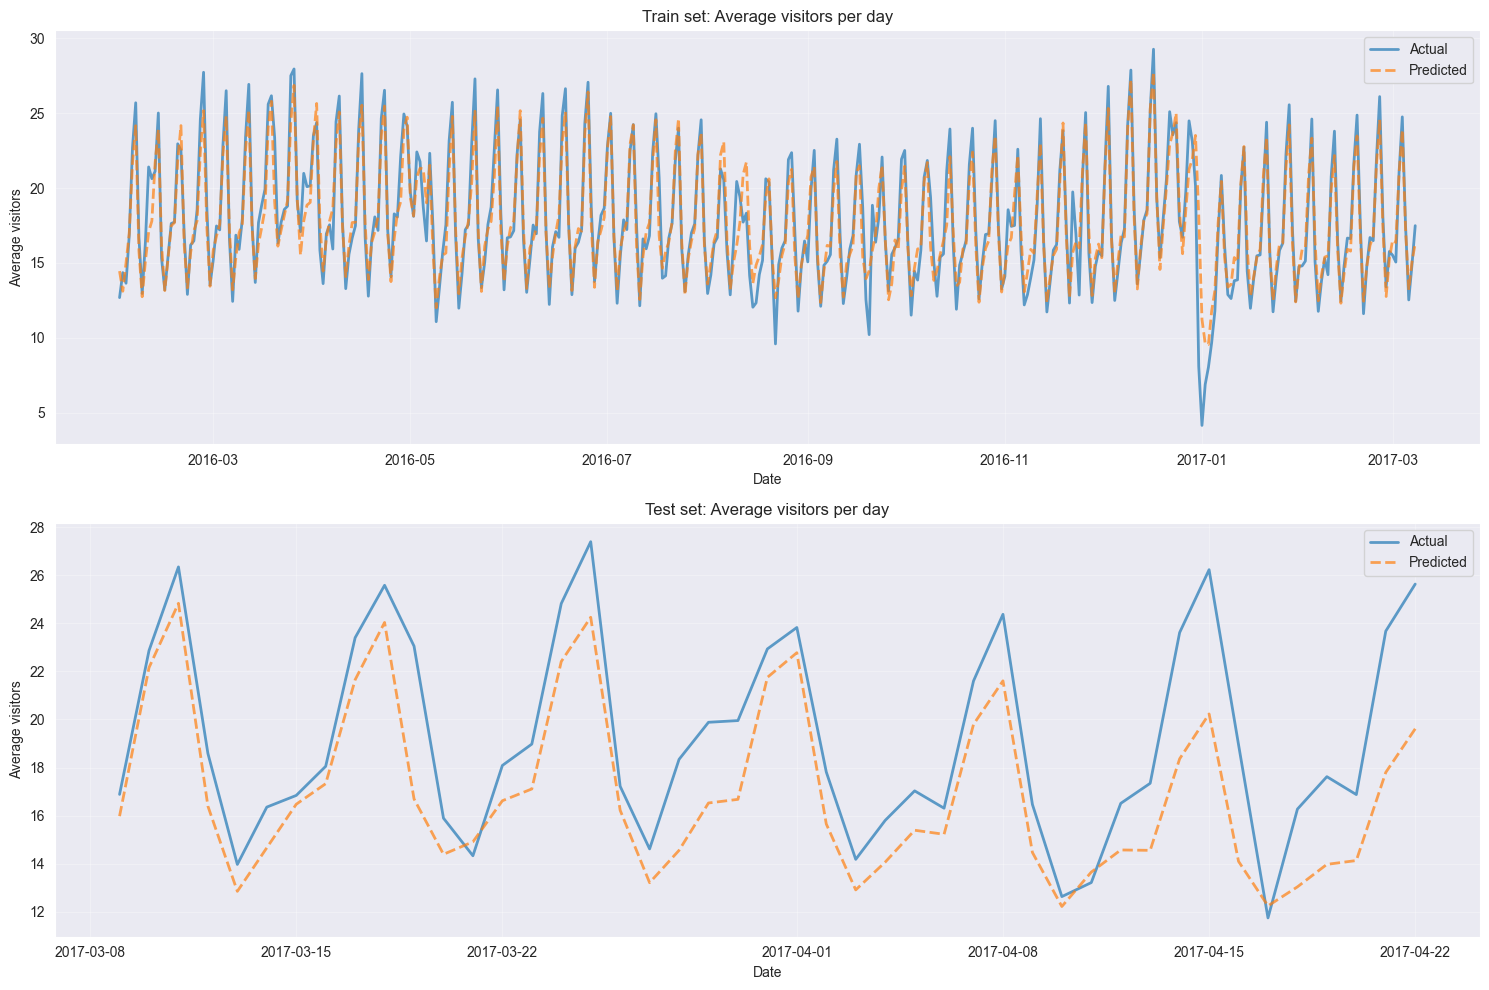

In [137]:
y_train_pred = pd.Series(y_train_pred, name="predicted")
train_daily = merge_daily_pred(train_dates, y_train, y_train_pred)
test_daily = merge_daily_pred(test_dates, y_test, y_test_pred)

fig, axes = plt.subplots(2, 1, figsize=(15, 10))

plot_actual_pred(axes[0], train_daily, "Train set")
plot_actual_pred(axes[1], test_daily, "Test set")

plt.tight_layout()
plt.show()

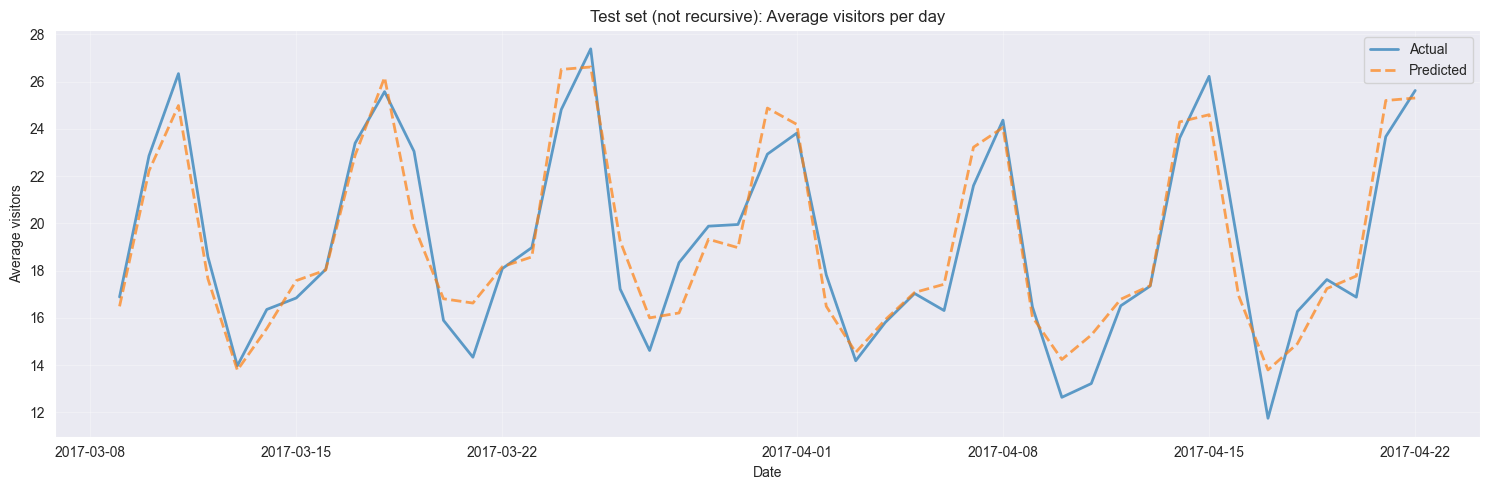

In [53]:
y_test_nr_pred = model.predict(X_test)
y_test_nr_pred = pd.Series(y_test_nr_pred, name="predicted")
test_daily = merge_daily_pred(test_dates, y_test, y_test_nr_pred)
fig, axes = plt.subplots(figsize=(15, 5))
plot_actual_pred(axes, test_daily, "Test set (not recursive)")
plt.tight_layout()
plt.show()

In [25]:
(y_test - y_test_nr_pred).mean()

np.float64(-0.08540328752651448)

Systematic underprediction arises from the accumulation of recursion error.

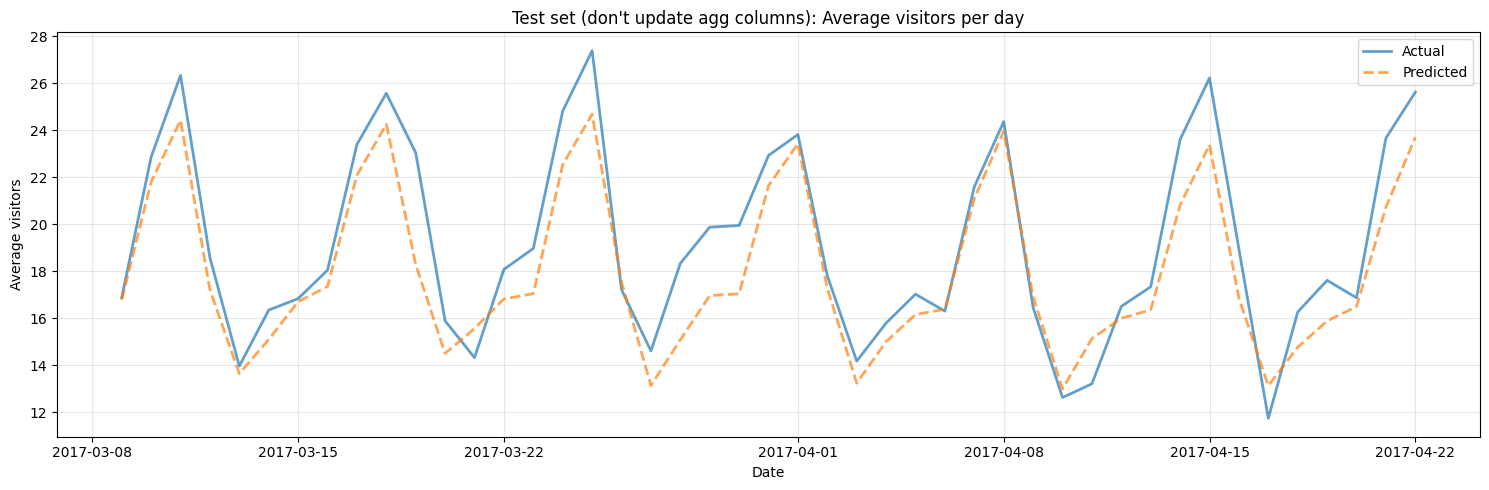

In [26]:
test_daily = merge_daily_pred(test_dates, y_test, y_test_pred)
fig, axes = plt.subplots(figsize=(15, 5))
plot_actual_pred(axes, test_daily, "Test set (don't update agg columns)")
plt.tight_layout()
plt.show()

In [27]:
(y_test - y_test_nr_pred).mean()

np.float64(1.1528426476567775)

### Residuals

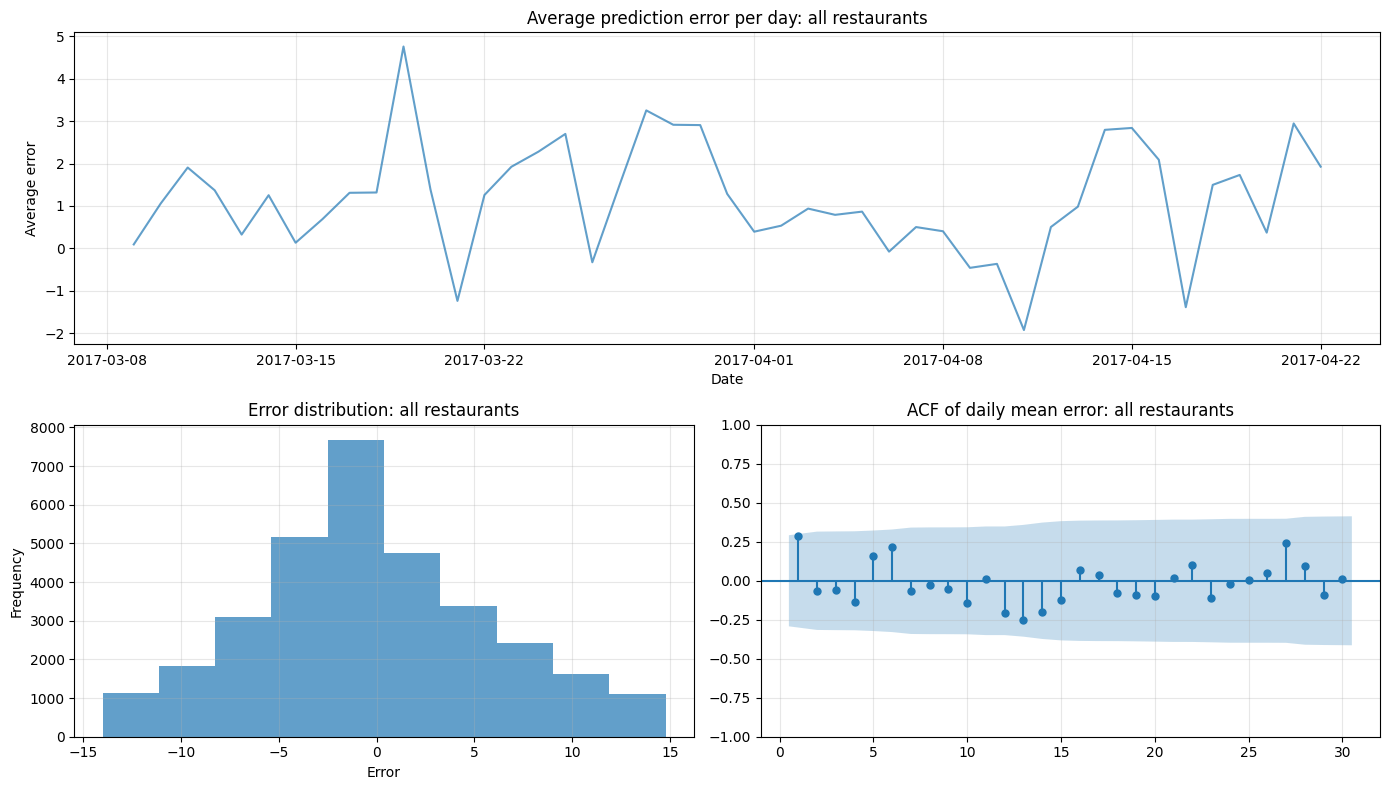

In [30]:
plot_daily_error_overall(X_test, y_test_pred, y_test)

The residuals have some seasonality, so it is likely that some dependence is not taken into account.

#### Cities

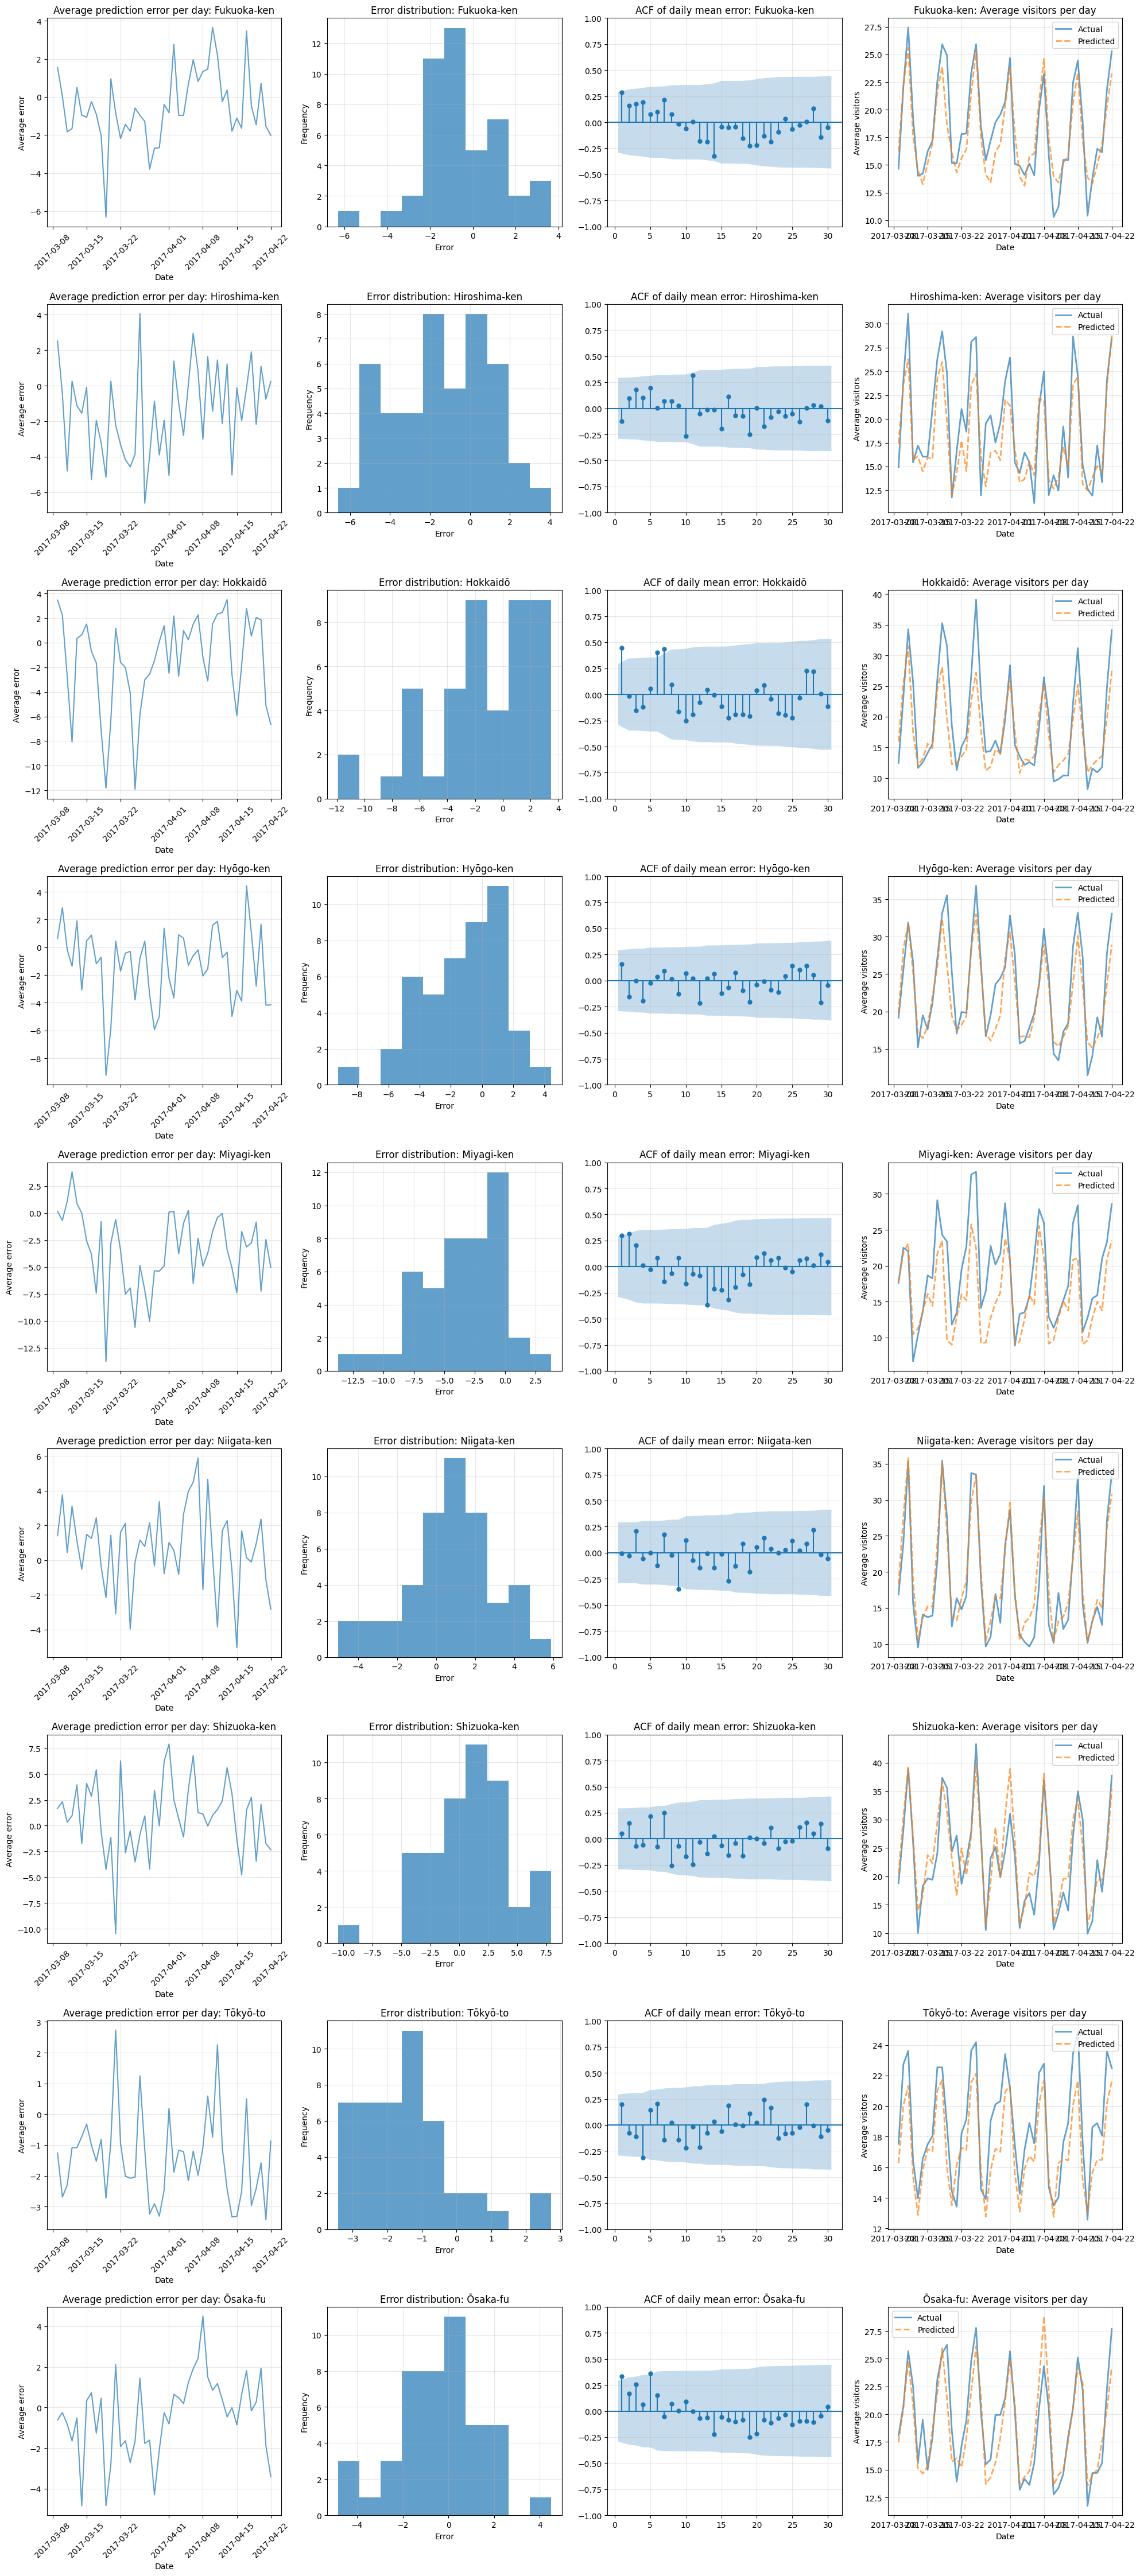

In [31]:
plot_daily_error_by_group(X_test, y_test, y_test_pred, CITY_COL)

The residuals averaged across cities don't differ significantly from each other on average. For most of them, the mean error increases between 2017-03 and 2017-04, but in some cities it's larger, and in others, smaller.

In [32]:
city_group_error_info = get_daily_error_stats_table(X_test, y_test, y_test_pred, CITY_COL)
city_group_error_info

,city,mean_error,std_error,min_abs_error,max_pos_error,max_neg_error,acf_1,acf_2,acf_3,acf_4,acf_5,acf_6,acf_7,acf_8,acf_9,acf_10,acf_11,acf_12,acf_13,acf_14
0,Fukuoka-ken,-0.538,1.859,0.035,3.653,6.310,0.293,0.166,0.184,0.204,0.080,0.110,0.239,0.086,-0.017,-0.067,0.011,-0.242,-0.263,-0.482
1,Hiroshima-ken,-1.438,2.523,0.063,4.064,6.611,-0.126,0.101,0.190,0.111,0.216,-0.001,0.070,0.078,0.029,-0.325,0.404,-0.058,-0.012,-0.007
2,Hokkaidō,-1.502,3.815,0.084,3.494,11.915,0.469,-0.015,-0.164,-0.134,0.066,0.464,0.509,0.113,-0.194,-0.318,-0.272,-0.105,0.079,0.005
3,Hyōgo-ken,-1.282,2.676,0.180,4.435,9.235,0.160,-0.164,-0.002,-0.210,-0.022,0.041,0.114,0.020,-0.156,0.093,0.030,-0.336,0.031,0.102
4,Miyagi-ken,-3.470,3.501,0.020,3.799,13.755,0.305,0.321,0.222,0.014,-0.032,0.104,-0.170,-0.075,0.113,-0.202,-0.099,-0.129,-0.567,-0.330
5,Niigata-ken,0.734,2.349,0.093,5.894,5.031,-0.007,-0.030,0.221,-0.058,0.003,-0.127,0.195,-0.020,-0.409,0.158,-0.087,-0.183,-0.005,-0.201
6,Shizuoka-ken,0.840,3.538,0.007,7.919,10.475,0.054,0.157,-0.069,-0.062,0.229,-0.078,0.279,-0.279,-0.072,-0.192,-0.295,-0.033,-0.204,0.033
7,Tōkyō-to,-1.433,1.397,0.187,2.732,3.427,0.199,-0.079,-0.113,-0.328,0.154,0.223,-0.158,0.029,-0.165,-0.258,-0.020,-0.291,-0.114,0.056
8,Ōsaka-fu,-0.401,1.944,0.008,4.495,4.841,0.342,0.176,0.270,0.068,0.384,0.174,-0.060,0.080,0.005,0.105,0.005,-0.080,-0.077,-0.293


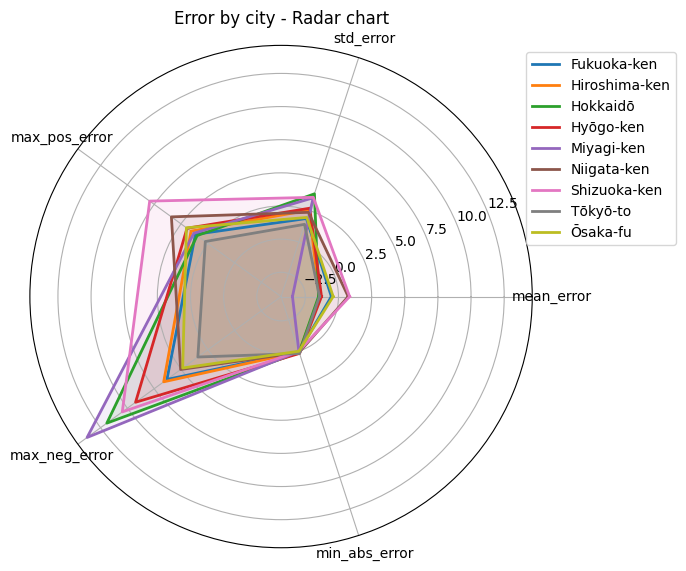

In [33]:
categories = [
    MEAN_ERROR,
    STD_ERROR,
    MAX_POS_ERROR,
    MAX_NEG_ERROR,
    MIN_ABS_ERROR
]
plot_error_radar(city_group_error_info, CITY_COL, categories, False)

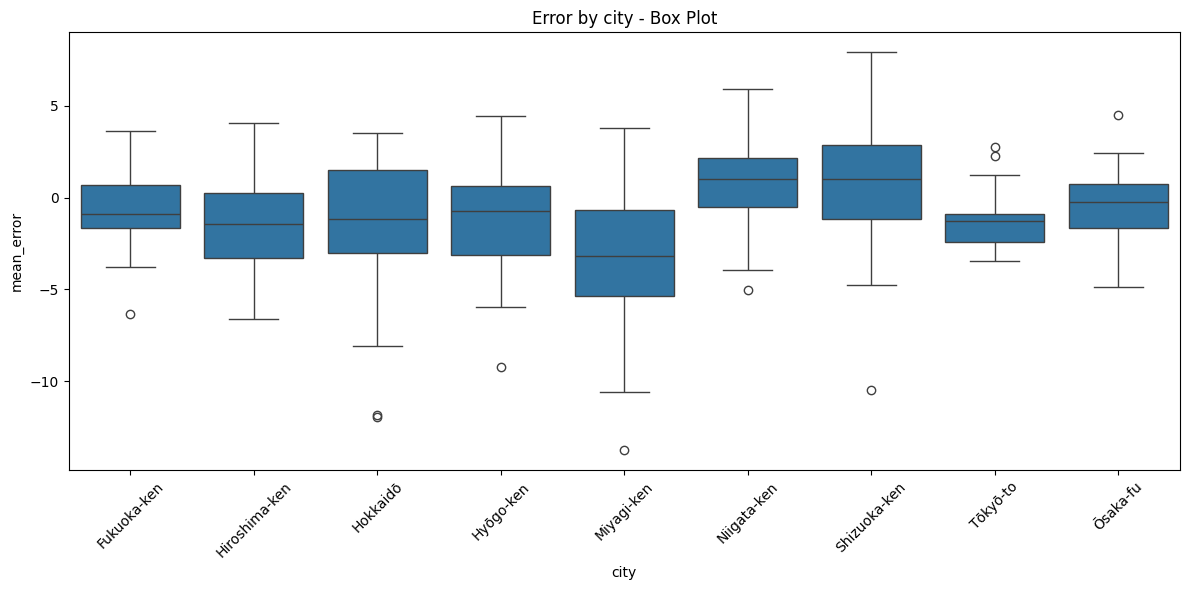

In [34]:
plot_errors_boxplot(X_test, y_test, y_test_pred, CITY_COL)

#### Genres

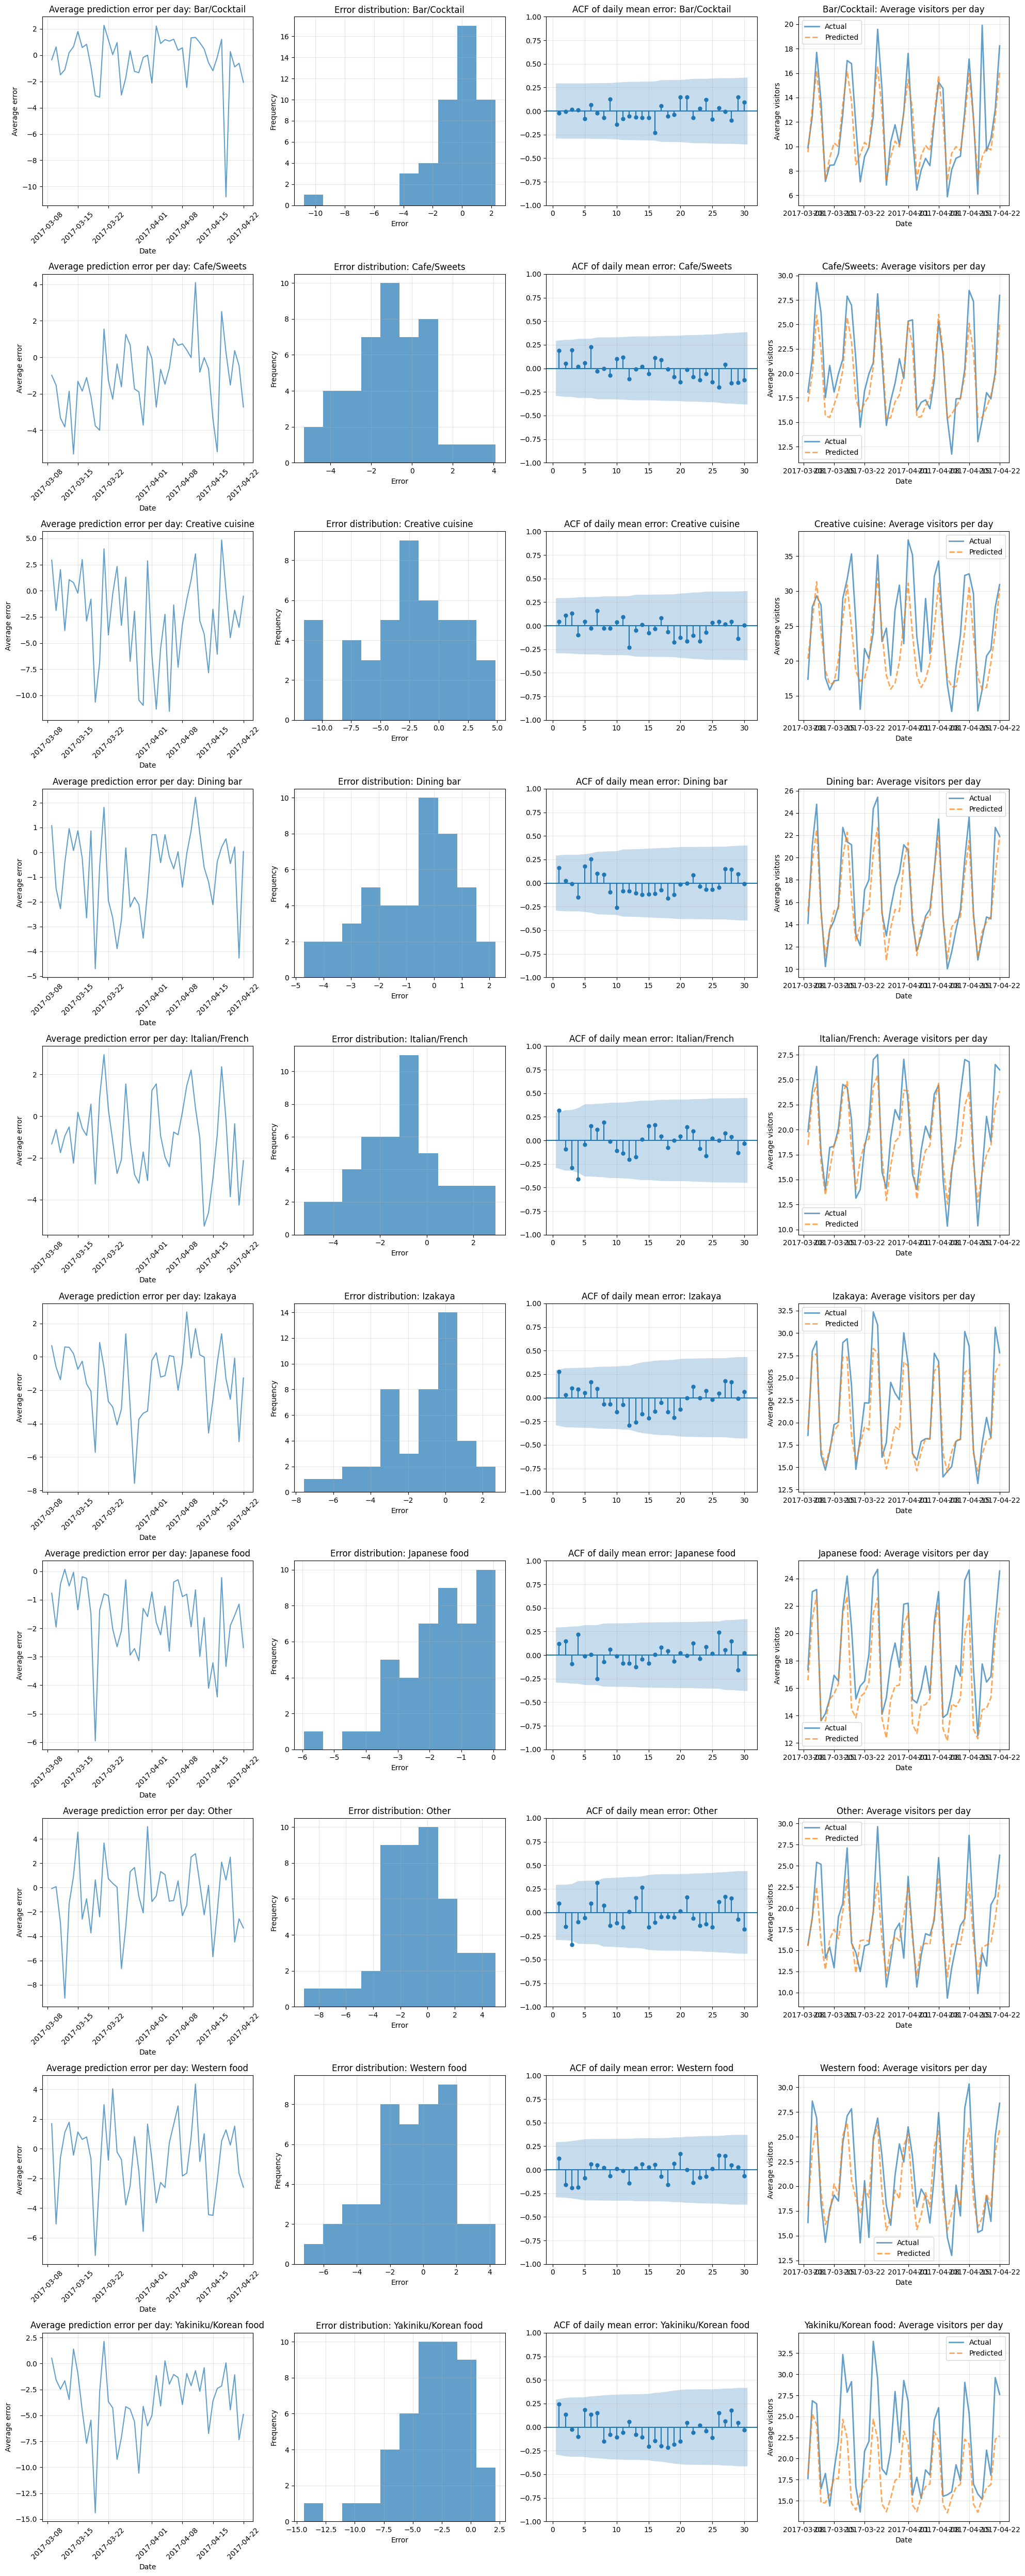

In [35]:
plot_daily_error_by_group(X_test, y_test, y_test_pred, AIR_GENRE_COL)

The largest residuals are observed for restaurants with the Asian and Karaoke/Party genres. However, firstly, the model doesn't consider the genre_te parameter. And if we recall the previous analysis, we see that there are fewer than five restaurants for each of these genres. Creating a different model for them is a questionable idea, but we can try removing the genre with some threshold and retraining the model.

In [36]:
genre_group_error_info = get_daily_error_stats_table(X_test, y_test, y_test_pred, AIR_GENRE_COL)
genre_group_error_info

,air_genre_name,mean_error,std_error,min_abs_error,max_pos_error,max_neg_error,acf_1,acf_2,acf_3,acf_4,acf_5,acf_6,acf_7,acf_8,acf_9,acf_10,acf_11,acf_12,acf_13,acf_14
0,Bar/Cocktail,-0.359,2.114,0.007,2.268,10.775,-0.024,-0.005,0.016,0.012,-0.126,0.107,-0.026,-0.106,0.217,-0.220,-0.130,-0.100,-0.121,-0.122
1,Cafe/Sweets,-1.112,1.943,0.016,4.094,5.308,0.189,0.050,0.200,0.020,0.065,0.279,-0.039,-0.009,-0.096,0.138,0.166,-0.151,0.021,0.073
2,Creative cuisine,-2.627,4.373,0.003,4.849,11.541,0.045,0.110,0.137,-0.102,0.043,-0.033,0.173,-0.037,-0.036,0.046,0.111,-0.295,-0.077,0.004
3,Dining bar,-0.750,1.618,0.022,2.221,4.708,0.164,0.025,-0.010,-0.163,0.198,0.286,0.113,0.106,-0.114,-0.312,-0.115,-0.118,-0.169,-0.189
4,Italian/French,-1.043,1.898,0.171,2.951,5.274,0.317,-0.098,-0.301,-0.441,-0.047,0.175,0.131,0.222,-0.010,-0.144,-0.190,-0.284,-0.269,0.029
5,Izakaya,-1.316,2.109,0.016,2.683,7.582,0.280,0.033,0.108,0.101,0.058,0.185,0.107,-0.073,-0.074,-0.170,-0.091,-0.384,-0.343,-0.252
6,Japanese food,-1.680,1.300,0.035,0.070,5.954,0.122,0.150,-0.096,0.229,-0.010,0.007,-0.290,-0.070,0.118,0.022,-0.111,-0.119,-0.180,-0.038
7,Other,-0.694,2.793,0.031,5.001,9.099,0.098,-0.150,-0.360,-0.126,-0.071,0.117,0.408,0.099,-0.193,-0.166,-0.229,0.007,0.240,0.410
8,Western food,-0.642,2.521,0.230,4.356,7.198,0.124,-0.169,-0.206,-0.202,-0.095,0.064,0.056,0.028,-0.074,0.019,-0.011,-0.199,0.024,0.086
9,Yakiniku/Korean food,-3.513,3.194,0.059,2.136,14.398,0.250,0.143,-0.023,-0.108,0.195,0.150,0.165,-0.171,-0.089,-0.129,-0.080,0.082,-0.129,-0.171


### Overpredictions / underpredictions

In [37]:
res_df = pd.DataFrame({"actual": y_test, "residual": y_test - y_test_pred})
res_df.corr()

,actual,residual
actual,1.000000,0.691475
residual,0.691475,1.000000


In [38]:
res_df["residual"].mean()

np.float64(1.1528426476567775)

In [39]:
(y_train - y_train_pred).mean()

np.float64(0.029226923796711678)

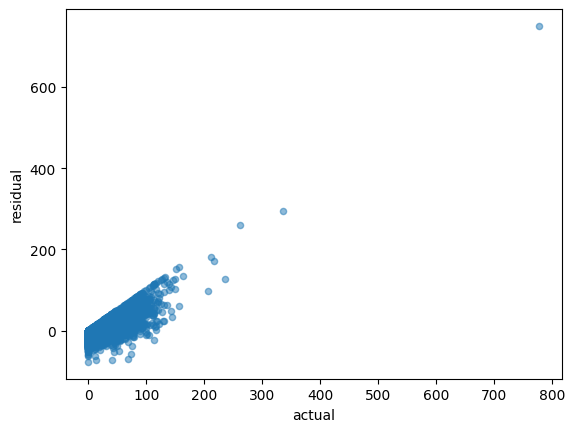

In [40]:
res_df.plot.scatter(x="actual", y="residual", alpha=0.5)
plt.show()

(0.0, 200.0)

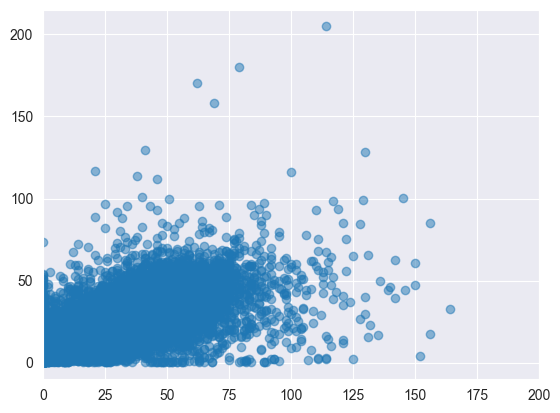

In [238]:
plt.scatter(y_test, y_test_pred, alpha=0.5)
plt.xlim(0, 200)

In [43]:
test_q95 = y_test.quantile(0.99)
top_mask = y_test > test_q95
X_top = X_test.loc[top_mask]
X_normal = X_test.loc[~top_mask]

In [44]:
num_cols = X_test.select_dtypes(include=np.number).columns
X_top_num = X_top[num_cols]
X_normal_num = X_normal[num_cols]

In [46]:
feature_means = pd.DataFrame({"top": X_top_num.mean(), "normal": X_normal_num.mean()})
feature_means["ratio"] = feature_means["top"] / feature_means["normal"]
feature_means.sort_values("ratio", ascending=False)

,top,normal,ratio
total_reservations_39,1.638122,0.081335,20.140480
total_reservations_38,1.638122,0.084319,19.427658
total_reservations_37,1.676796,0.091590,18.307667
total_reservations_36,1.754144,0.096175,18.239135
total_reservations_35,1.754144,0.102984,17.033123
...,...,...,...
holiday_to_workday_flg,0.016575,0.022246,0.745048
reservation_impossibility_flag,0.497238,0.694845,0.715609
nbr_res_visitors_diff,-1.911291,-2.895764,0.660030
golden_week_flg,0.000000,0.000000,NaN


C:\Users\lymuthien\AppData\Local\Temp\ipykernel_23820\3491025457.py:12: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values_under, X_under_clean)


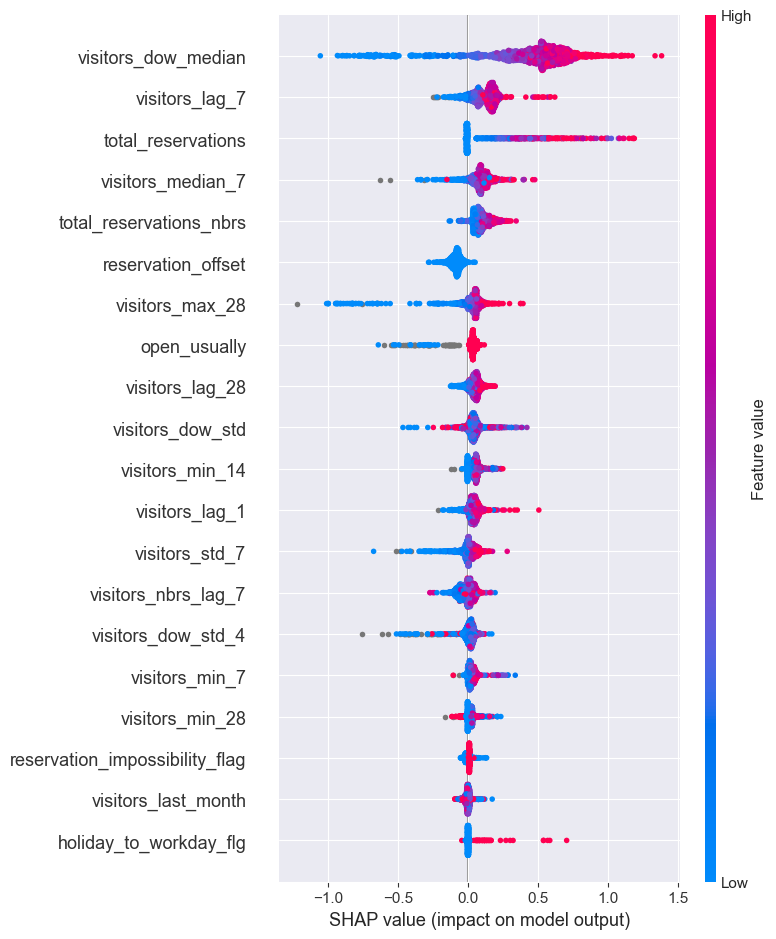

In [257]:
underpred = (
    (y_test >= test_q95) & (res_df["residual"] >= res_df["residual"].quantile(0.90))
)
X_under = test_temp.drop(columns=[VISITORS_COL]).tail(len(y_test)).reset_index(drop=True).loc[underpred]
X_under_clean = model.named_steps["feature_dropper"].transform(X_under)

shap_values_under = explainer(X_under_clean)
shap.summary_plot(shap_values_under, X_under_clean)

#### Lag_7 dependencies

(0.0, 200.0)

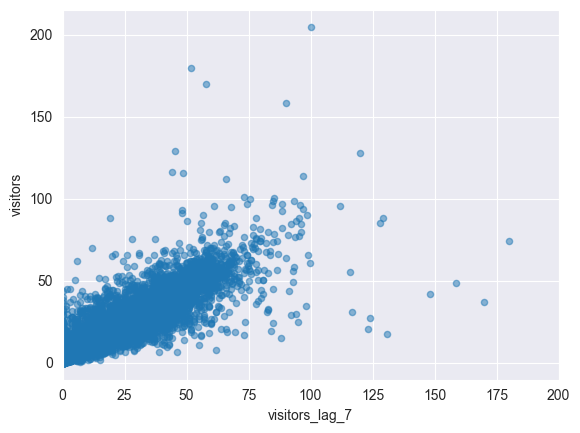

In [71]:
X_test_temp = test_temp.tail(len(y_test_pred))
X_test_temp.plot.scatter(x="visitors_lag_7", y=VISITORS_COL, alpha=0.5)
plt.xlim(0, 200)

#### Reservations influence

In [124]:
y_test_res_leak, _ = recursive_predict(
    model, X_test, X_train, y_train, update_reservations=False, update_dow_agg=False
)

Predicting recursively: 100%|██████████| 45/45 [00:13<00:00,  3.35it/s]


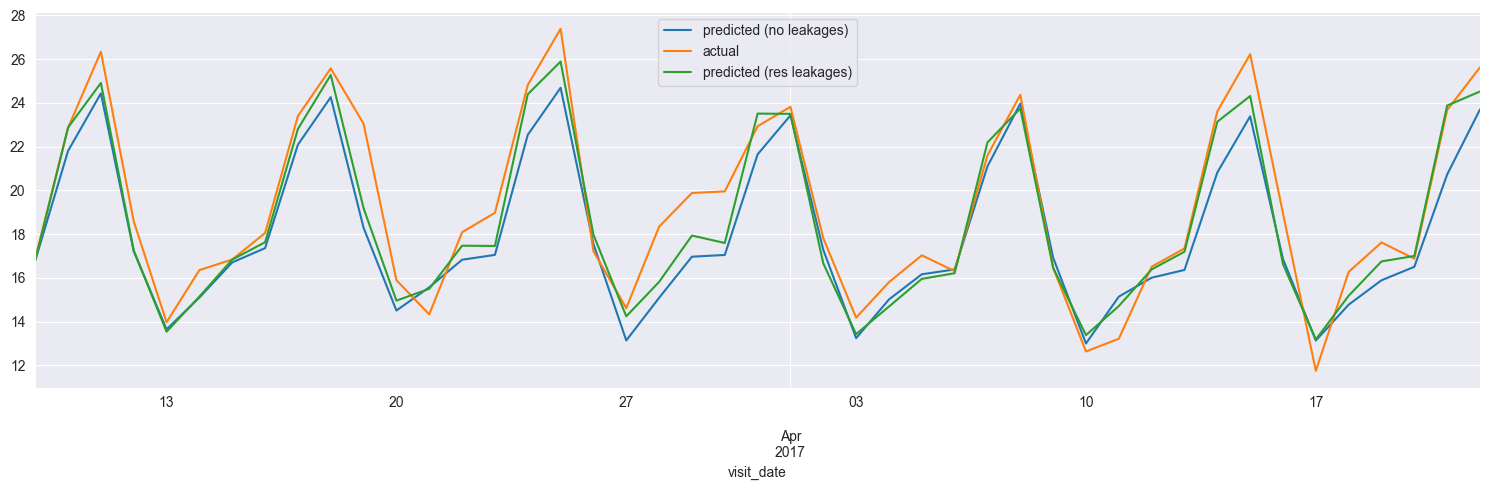

In [134]:
test_daily = merge_daily_pred(test_dates, y_test, y_test_pred)
fig, axes = plt.subplots(figsize=(15, 5))
test_daily.plot(x=VISIT_DATE_COL, y="predicted_mean", label="predicted (no leakages)", ax=axes)
test_daily.plot(x=VISIT_DATE_COL, y="actual_mean", label="actual", ax=axes)

test_daily = merge_daily_pred(test_dates, y_test, y_test_res_leak)
test_daily.plot(x=VISIT_DATE_COL, y="predicted_mean", label="predicted (res leakages)", ax=axes)
plt.tight_layout()
plt.show()

## Testing on future data

In [23]:
test_features = pd.read_csv(PROCESSED_DATA_DIR / "test_features.csv")
test_features = prepare_features(test_features)
test_features = test_features.reset_index(drop=True)
test_features["reservation_offset"] = 1

C:\Users\lymuthien\AppData\Local\Temp\ipykernel_23820\3014071253.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  test_features["reservation_offset"] = 1


In [113]:
test_labels, temp_features = recursive_predict(
    model,
    test_features,
    X,
    y,
    drop_cols=DROP_COLUMNS,
    update_reservations=True,
    update_dow_agg=False
)

Predicting recursively: 100%|██████████| 39/39 [00:14<00:00,  2.77it/s]


In [116]:
labels_format = get_format(test_features, test_labels)
labels_format.to_csv(PROCESSED_DATA_DIR / "test_labels.csv", index=False)

In [114]:
dates_and_pred = test_features.merge(test_labels.rename(VISITORS_COL), left_index=True, right_index=True)

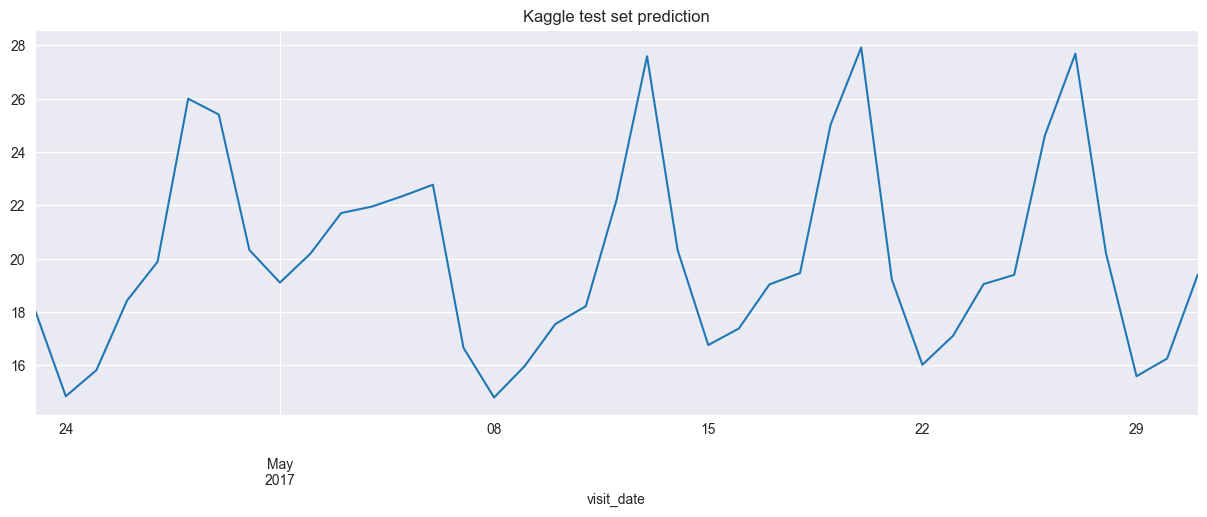

In [119]:
dates_and_pred.groupby(VISIT_DATE_COL)[VISITORS_COL].mean().plot(figsize=(15, 5))
plt.title("Kaggle test set prediction")
plt.show()

## GW prediction

### Only GW period

In [33]:
gw_mask = X_train[GOLDEN_WEEK_FLG] == 1
X_gw = X_train[gw_mask]
y_gw = y_train[gw_mask]
before_gw_mask = X_train[VISIT_DATE_COL] < X_gw[VISIT_DATE_COL].min()
X_before_gw = X_train[before_gw_mask]
y_before_gw = y_train[before_gw_mask]

In [34]:
y_test_gw, _ = recursive_predict(
    model,
    X_gw,
    X_before_gw,
    y_before_gw,
    update_reservations=True,
    update_dow_agg=False,
)

Predicting recursively: 100%|██████████| 7/7 [00:03<00:00,  1.81it/s]


In [35]:
gw_rmsle = rmsle(y_gw, y_test_gw)
print("Golden week")
get_metrics(y_gw, y_test_gw)

Golden week


RMSLE      1.252750
MAE       11.358787
MSE      317.074413
dtype: float64

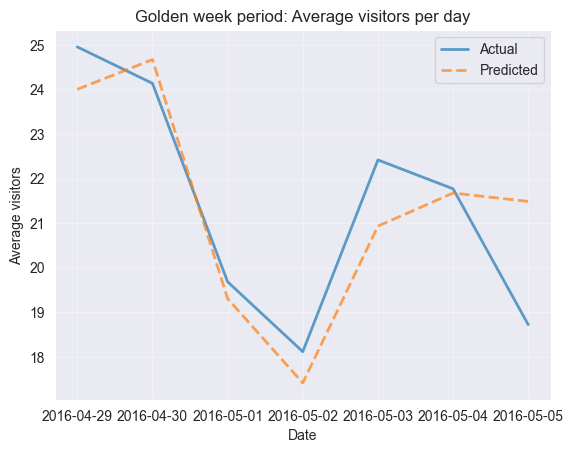

In [36]:
daily = merge_daily_pred(X_gw[VISIT_DATE_COL], y_gw, y_test_gw)
fig, axes = plt.subplots()
plot_actual_pred(axes, daily, "Golden week period")
plt.show()

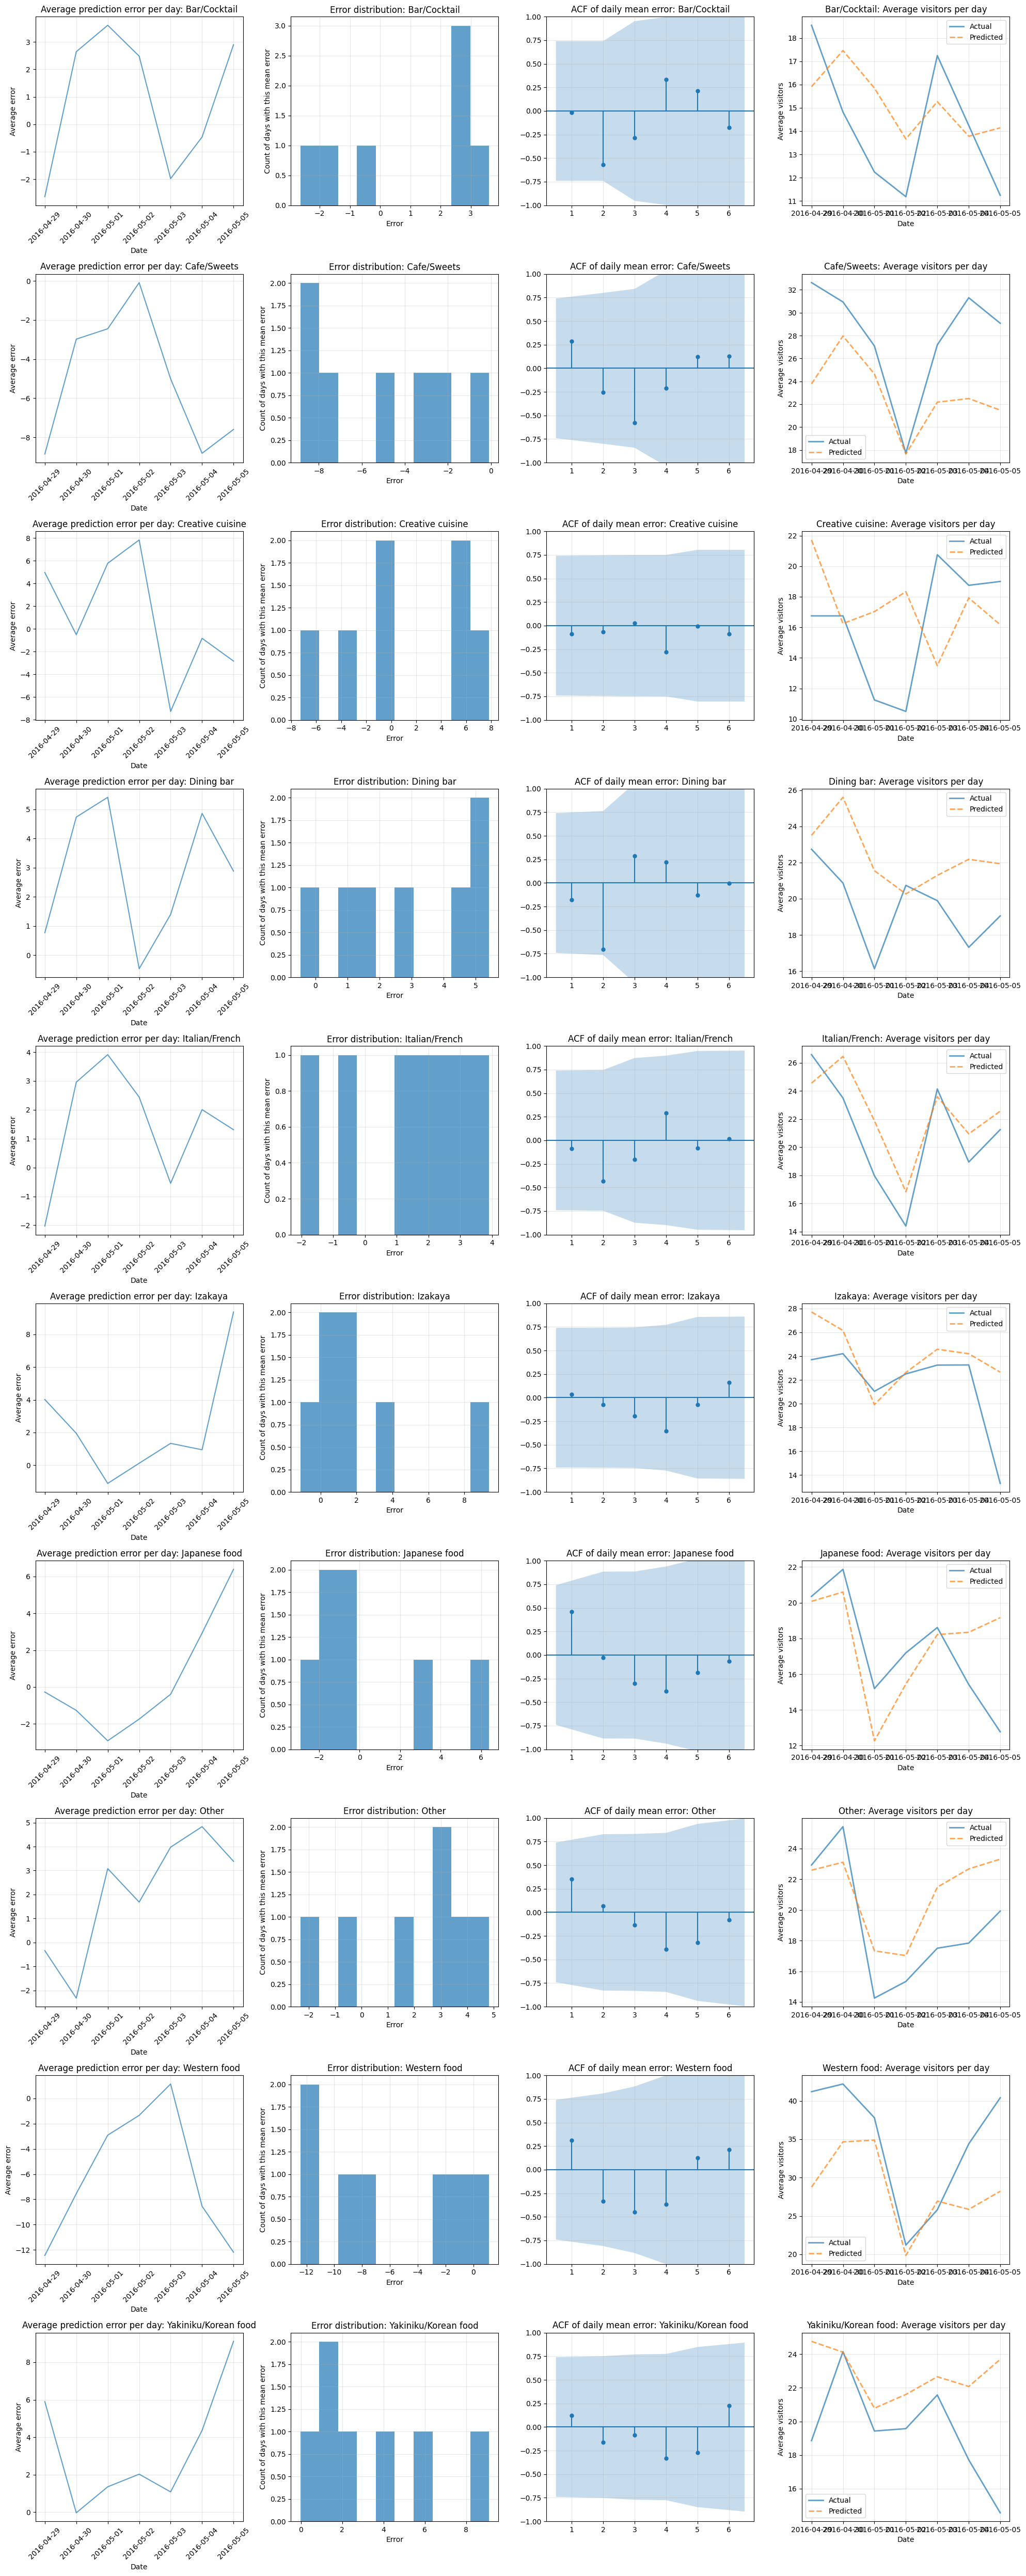

In [18]:
plot_daily_error_by_group(X_gw, y_gw, y_test_gw, AIR_GENRE_COL)

A significantly large average error is observed compared to the average error for the entire dataset. The largest difference between predicted and actual numbers is observed on Tuesdays and Wednesdays, the 3rd and 4th. These days typically have fewer visitors, leading the model to predict significantly fewer visitors than the actual number.

The situation is similar across genres: the final days are underpredicted across all genres.

### 39-day prediction

In [107]:
min_test_date = test_features[VISIT_DATE_COL].min()
min_year_ago = min_test_date - pd.DateOffset(years=1)
test_year_ago_dates = pd.date_range(min_year_ago, min_year_ago + pd.DateOffset(days=39))

In [108]:
X_train_before_gw = X_train[X_train[VISIT_DATE_COL] < min_year_ago]
y_train_before_gw = y_train.loc[X_train_before_gw.index]
X_year_ago = X_train[X_train[VISIT_DATE_COL].isin(test_year_ago_dates)]
y_year_ago = y_train.loc[X_year_ago.index]

In [109]:
yar_ago_labels, ya_temp_features = recursive_predict(
    model,
    X_year_ago,
    X_train_before_gw,
    y_train_before_gw,
    update_reservations=True,
    update_dow_agg=False
)

Predicting recursively: 100%|██████████| 40/40 [00:03<00:00, 11.78it/s]


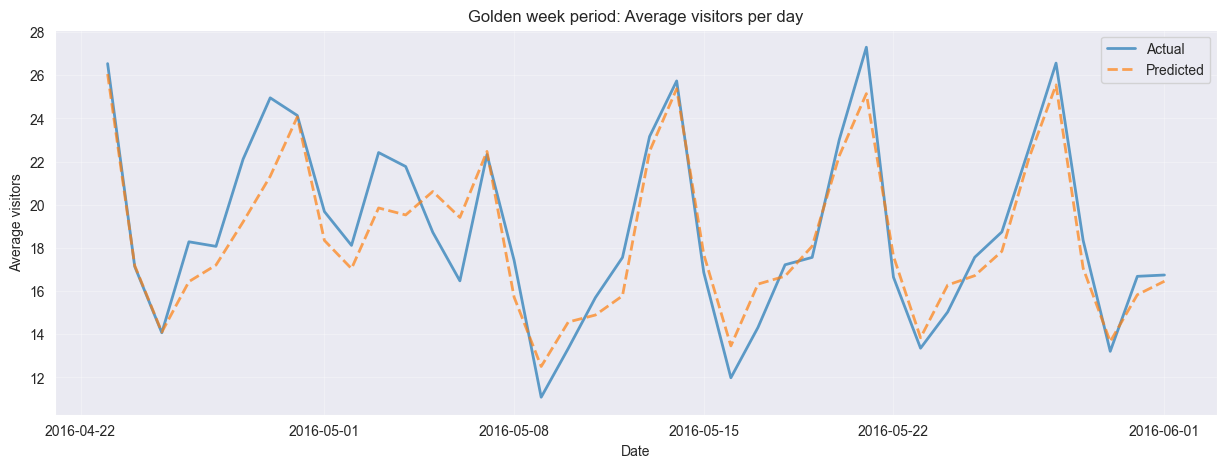

In [118]:
daily = merge_daily_pred(X_year_ago[VISIT_DATE_COL], y_year_ago, yar_ago_labels)
fig, axes = plt.subplots(figsize=(15, 5))
plot_actual_pred(axes, daily, "Golden week period")
plt.show()

## Saving model

In [143]:
kaggle_score = 0.57942

if MLFLOW_WORK:
    with mlflow.start_run(run_name=MODEL_NAME):
        best_cv_result = cv_results.sort_values("rank_test_score").iloc[0].to_dict()
        mlflow.log_dict(
            best_cv_result,
            artifact_file="best_cv_result.json"
        )

        mlflow.log_param("cv_splits", CV_SPLITS)
        mlflow.log_param("score_gw_flg", True)
        mlflow.log_param("test_size", TEST_SIZE)
        mlflow.log_param("feature_selection_validation_size", FS_VALID_SIZE)
        mlflow.log_param("first_iteration_n_trials", FIRST_ITER_TRIALS)
        mlflow.log_param("second_iteration_n_trials", 0)
        mlflow.log_param("objective_function", OBJECTIVE_FUNCTION)
        mlflow.log_param("cluster_cities", False)
        mlflow.log_params(best_cv_result["params"])
        mlflow.log_param("mix_reservations", MIX_RESERVATIONS)
        mlflow.log_param("include_gap", INCLUDE_GAP)

        mlflow.log_metric("test_rmsle", test_rmsle)
        mlflow.log_metric("kaggle_rmsle", kaggle_score)
        mlflow.log_metric("cv_mean_test_score", best_cv_result["mean_test_score"])
        mlflow.log_metric("cv_std_test_score", best_cv_result["std_test_score"])
        mlflow.log_metric("gw_score", gw_rmsle)
        for i in range(CV_SPLITS):
            mlflow.log_metric(f"cv_split_{i}_score", best_cv_result[f"split_test_{i}"])

        mlflow.sklearn.log_model(
            sk_model=model,
            name=MODEL_NAME
        )

        mlflow.set_tags({
            "feature_ranking_method": None,
            "feature_selection_strategy": None,
            "training_window_size": 39,
            "max_depth": "enabled",
            "fill_gaps": "no filling; don't include period",
        })

2026/05/23 17:44:26 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/05/23 17:44:35 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
